In [1]:
# =========================
# Imports
# =========================
import os
import time
import json
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

import Emulator.Models.misc as misc
import Emulator.Inference.kolmogorov.performance as performance
import Emulator.Inference.kolmogorov.util as util
import Emulator.Models.unet_modern as munet
import Emulator.Models.diffusion as diffusion


# =========================
# Robust checkpoint loader
# =========================
def load_checkpoint_any(path: str, map_location="cpu"):
    """
    Load a checkpoint saved via torch.save OR pickle.dump.
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except Exception as e_torch:
        try:
            with open(path, "rb") as f:
                return pickle.load(f)
        except Exception as e_pkl:
            raise RuntimeError(
                f"Failed to load checkpoint {path}\n"
                f"torch.load error: {repr(e_torch)}\n"
                f"pickle.load error: {repr(e_pkl)}"
            )


# =========================
# Main function
# =========================
def therm_inference_notebook(
    identifier: str,
    start: int,
    stop: int,
    steps: int,
    forward_diff: bool = True,
    emulator: str = "/scratch/ql2221/Emulator_models/wandb_data/wandb/run-20251209_020651-5dziwzqp/files/checkpoint_best.p",
    thermalizer: str = "/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20260119_154941-l9ewhjig/files/checkpoint_last.p",
    save_dir: str = "/scratch/ql2221/thermalizer_data/icml_inferences",
    cache_dir: str = "/scratch/ql2221/thermalizer_data/icml_inferences/cached_runs/kolmogorov",
    silence: bool = False,
    device: str = "cuda",
    show_plots: bool = True,
):

    # ----------------------------
    # Setup paths
    # ----------------------------
    run_dir = os.path.join(save_dir, identifier)
    fig_dir = os.path.join(run_dir, "figures")
    os.makedirs(fig_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    config = dict(
        identifier=identifier,
        start=start,
        stop=stop,
        steps=steps,
        forward_diff=forward_diff,
        emulator=emulator,
        thermalizer=thermalizer,
        device=device,
    )

    print("Run dir:", run_dir)
    print("Therm start:", start, "Therm stop:", stop)

    # ----------------------------
    # Load emulator
    # ----------------------------
    model_emu = misc.load_model(emulator).to(device).eval()

    # ----------------------------
    # Load thermalizer (pickle OR torch)
    # ----------------------------
    model_dict = load_checkpoint_any(thermalizer, map_location="cpu")

    # unwrap common wrappers
    if "checkpoint" in model_dict:
        model_dict = model_dict["checkpoint"]
    if "model" in model_dict and "state_dict" in model_dict["model"]:
        model_dict = model_dict["model"]

    cfg = model_dict["config"]
    sd = model_dict["state_dict"]

    mt = cfg.get("model_type")
    if mt == "ModernUnet":
        model_cnn = munet.ModernUnet(cfg)
    elif mt == "ModernUnetRegressor":
        model_cnn = munet.ModernUnetRegressor(cfg)
    else:
        raise RuntimeError(f"Unknown model_type={mt}")

    try:
        model_cnn.load_state_dict(sd, strict=True)
    except RuntimeError:
        sd = {k.replace("module.", ""): v for k, v in sd.items()}
        model_cnn.load_state_dict(sd, strict=False)

    model_cnn = model_cnn.to(device).eval()
    model_therm = diffusion.Diffusion(cfg, model=model_cnn).to(device).eval()

    # ----------------------------
    # Save config
    # ----------------------------
    with open(os.path.join(run_dir, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    # ----------------------------
    # Load data (CPU), extract ICs, then delete data
    # ----------------------------
    test_suite = torch.load(
        "/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p",
        map_location="cpu",
    )
    data = (test_suite["data"] / 4.44).contiguous()  # CPU tensor

    # Only keep what we need:
    # - emulator ICs: (B,1,64,64)
    # - therm ICs:    (B,64,64)
    ics_emu = data[:, 0:1].clone()
    ics_therm = data[:, 0].clone()

    # If you do NOT need ground-truth enstrophy, do not compute it.
    ens_true = None

    # Drop dataset to free CPU RAM and avoid accidental extra refs/copies
    del test_suite
    del data

    # Optional: clean up any cached GPU blocks (won't free tensors still referenced)
    if device.startswith("cuda") and torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ----------------------------
    # Emulator cache
    # ----------------------------
    emu_cache_dict = dict(
        emulator=emulator,
        thermalizer=thermalizer,
        steps=steps,
    )

    cache_list_path = os.path.join(cache_dir, "cache_list.p")
    cache_list = pickle.load(open(cache_list_path, "rb")) if os.path.exists(cache_list_path) else []

    loaded_cache = False
    for i, d in enumerate(cache_list):
        if d == emu_cache_dict:
            emu = [
                torch.load(os.path.join(cache_dir, f"emu_state_{i}.p")),
                torch.load(os.path.join(cache_dir, f"emu_enstr_{i}.p")),
                torch.load(os.path.join(cache_dir, f"emu_noise_class_{i}.p")),
            ]
            loaded_cache = True
            break

    if not loaded_cache:
        emu = performance.run_emu(
            ics_emu,          # << uses only initial condition batch
            model_emu,
            model_therm,
            steps,
            silent=silence,
        )
        i = len(cache_list)
        torch.save(emu[0], os.path.join(cache_dir, f"emu_state_{i}.p"))
        torch.save(emu[1], os.path.join(cache_dir, f"emu_enstr_{i}.p"))
        torch.save(emu[2], os.path.join(cache_dir, f"emu_noise_class_{i}.p"))
        cache_list.append(emu_cache_dict)
        pickle.dump(cache_list, open(cache_list_path, "wb"))

    # ----------------------------
    # Thermalization
    # ----------------------------
    t0 = time.time()
    algo = performance.therm_algo(
        ics_therm,          # << uses only initial condition batch
        model_emu,
        model_therm,
        steps,
        start,
        stop,
        forward=forward_diff,
        silent=silence,
    )
    algo_time = time.time() - t0
    exited = len(algo[0][1]) < steps - 1

    # ----------------------------
    # Save tensors
    # NOTE: You requested "does not save enstrophy"
    #       - We will NOT save ens_true (ground-truth)
    #       - We also skip the enstrophy plot below
    #       - (run_emu itself may still compute and return emu[1]; we just won't plot/save it here)
    # ----------------------------
    for i, t in enumerate(emu, 1):
        torch.save(t, os.path.join(run_dir, f"emu_{i}.pt"))
    for i, t in enumerate(algo, 1):
        torch.save(t, os.path.join(run_dir, f"therm_{i}.pt"))

    # ----------------------------
    # Plot helper
    # ----------------------------
    def save_show(fig, name):
        fig.savefig(os.path.join(fig_dir, f"{name}.png"), dpi=200, bbox_inches="tight")
        if show_plots:
            plt.show()
        plt.close(fig)

    # ----------------------------
    # (Removed) Enstrophy plot
    # ----------------------------
    # You asked to not save enstrophy, so we do not compute/plot/save ens_true here.

    # ----------------------------
    # Summary
    # ----------------------------
    summary = dict(
        exited=exited,
        algo_time_seconds=algo_time,
        total_therm=float(algo[-1].sum()),
    )
    with open(os.path.join(run_dir, "summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    print("Finished.")
    print(summary)

    return dict(
        config=config,
        summary=summary,
        emu=emu,
        algo=algo,
        ens_true=ens_true,  # None
    )


# =========================
# RUN IT
# =========================
out = therm_inference_notebook(
    identifier="debug_run_001",
    start=6,
    stop=4,
    steps=50000,
    forward_diff=True,
    show_plots=True,
)


Run dir: /scratch/ql2221/thermalizer_data/icml_inferences/debug_run_001
Therm start: 6 Therm stop: 4


/ext3/miniforge3/lib/python3.12/site-packages/Emulator/Models/misc.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)
/state/partition

Finished.
{'exited': False, 'algo_time_seconds': 1171.1624102592468, 'total_therm': 416738.0}


Run dir: /scratch/ql2221/thermalizer_data/icml_inferences/debug_qg_run_001
Thermalize start=10, stop=4, steps=20000, forward_diff=True


/ext3/miniforge3/lib/python3.12/site-packages/Emulator/Models/misc.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)
/state/partition

Running emulator (no cache hit).


100%|██████████| 19999/19999 [09:16<00:00, 35.91it/s]


Cached emulator run at index=0 in /scratch/ql2221/thermalizer_data/icml_inferences/cached_runs/qg


  0%|          | 0/19999 [00:04<?, ?it/s]

breaking due to noise limit at traj 0
Algo time (seconds) = 4.694157838821411


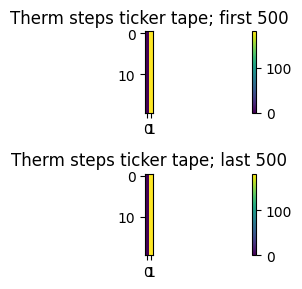

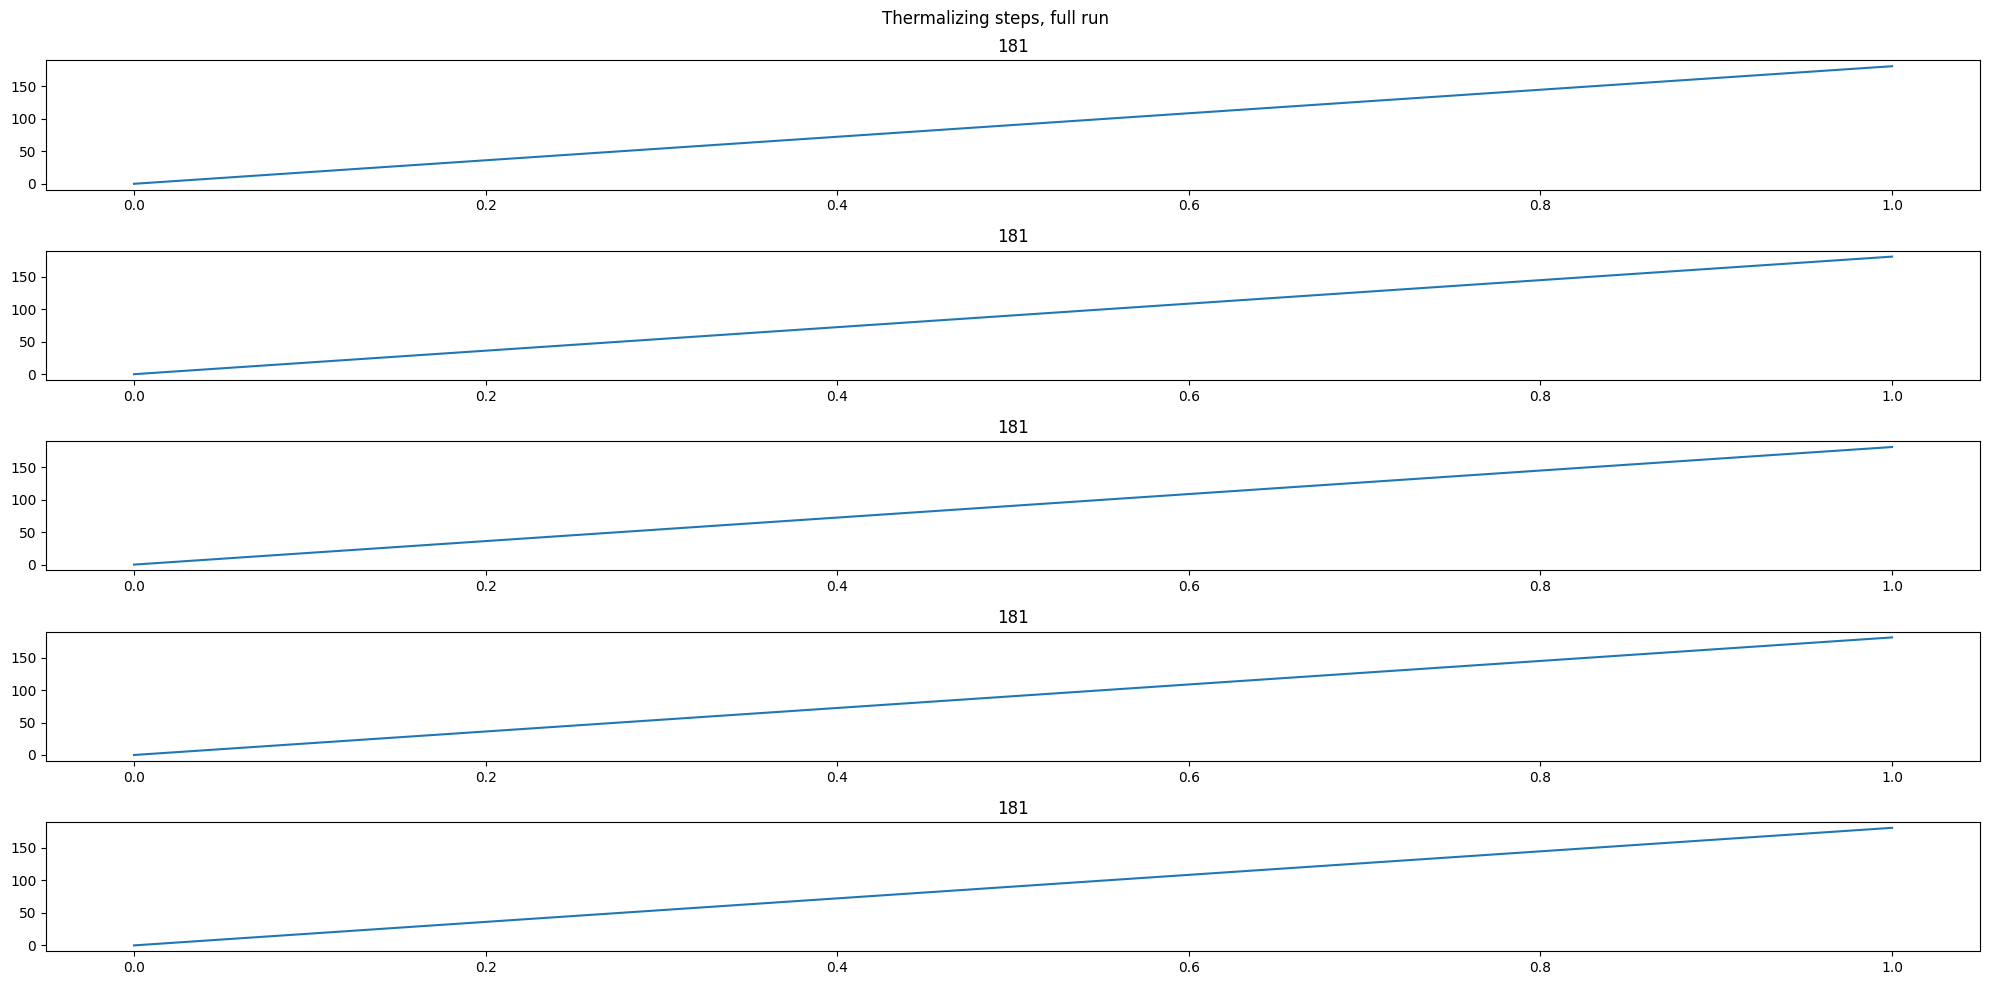

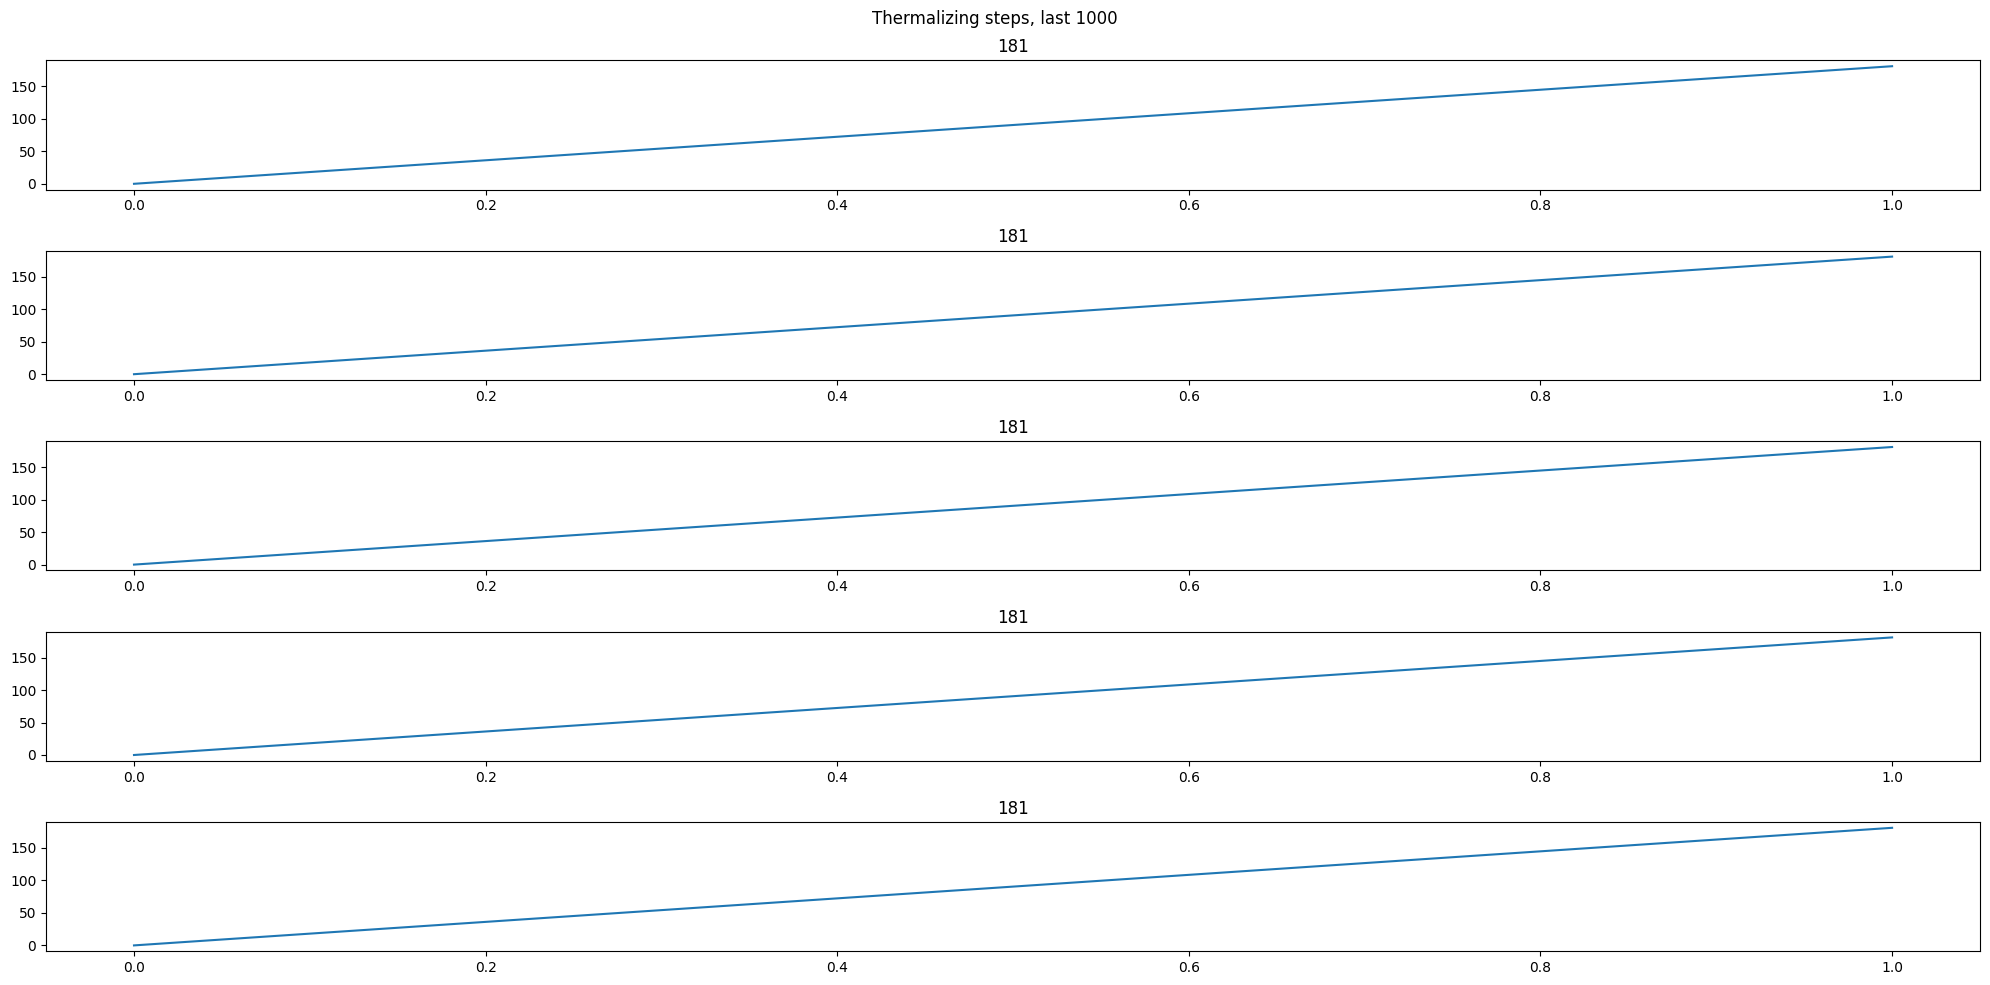

/ext3/miniforge3/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/ext3/miniforge3/lib/python3.12/site-packages/torch_qg/model.py:163: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.height_ratios = torch.tensor((self.Hi / self.H)[:,np.newaxis,np.newaxis],device=self.device, requires_grad=self.grad)


IndexError: index 1819 is out of bounds for dimension 1 with size 2

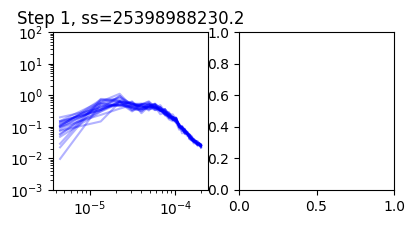

In [1]:
# =========================
# Imports (Notebook-friendly)
# =========================
import os
import time
import json
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

import Emulator.Models.misc as misc
import thermalizer.qg.performance as performance
import thermalizer.qg.util as util
import pickle
import Emulator.Models.unet_modern as munet
import Emulator.Models.diffusion as diffusion
import torch



# =========================
# Robust checkpoint loader
# =========================
def load_checkpoint_any(path: str, map_location="cpu"):
    """
    Load a checkpoint saved via torch.save OR pickle.dump.
    """
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except Exception as e_torch:
        try:
            with open(path, "rb") as f:
                return pickle.load(f)
        except Exception as e_pkl:
            raise RuntimeError(
                f"Failed to load checkpoint {path}\n"
                f"torch.load error: {repr(e_torch)}\n"
                f"pickle.load error: {repr(e_pkl)}"
            )


# =========================
# Small helper: save + (optional) show
# =========================
def save_show(fig, out_path: str, show_plots: bool):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    if show_plots:
        plt.show()
    plt.close(fig)


# =========================
# Main function (QG version)
# =========================
def therm_inference_qg_notebook(
    identifier: str,
    start: int,
    stop: int,
    steps: int,
    forward_diff: bool,
    emulator: str,
    thermalizer: str,
    test_suite_path: str,

    # output + caching
    save_dir: str,
    cache_dir: str,

    # runtime knobs
    device: str = "cuda",
    silence: bool = False,        # passed into your perf routines
    show_plots: bool = True,
    save_tensors: bool = True,
    save_figures: bool = True,

    # safety knobs
    use_cache: bool = True,
):
    """
    Notebook-friendly runner for QG thermalized inference.
    - No wandb
    - Saves config/summary
    - Saves tensors/figures optionally
    """

    # ----------------------------
    # Setup run directory
    # ----------------------------
    run_dir = os.path.join(save_dir, identifier)
    fig_dir = os.path.join(run_dir, "figures")
    os.makedirs(run_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)

    config = dict(
        identifier=identifier,
        start=int(start),
        stop=int(stop),
        steps=int(steps),
        forward_diff=bool(forward_diff),
        emulator=emulator,
        thermalizer=thermalizer,
        test_suite_path=test_suite_path,
        device=device,
        cache_dir=cache_dir,
        save_dir=save_dir,
    )

    print(f"Run dir: {run_dir}")
    print(f"Thermalize start={start}, stop={stop}, steps={steps}, forward_diff={forward_diff}")

    # ----------------------------
    # Load models
    # ----------------------------
    model_emu = misc.load_model(emulator).to(device).eval()

    # Preferred (your original path):
    # If this fails for some checkpoint formats, swap to a manual loader.
    with open(thermalizer, "rb") as f:
        model_dict = pickle.load(f)

    # build backbone
    if model_dict["config"]["model_type"] == "ModernUnet":
        model_cnn = munet.ModernUnet(model_dict["config"])
    elif model_dict["config"]["model_type"] == "ModernUnetRegressor":
        model_cnn = munet.ModernUnetRegressor(model_dict["config"])
    else:
        raise ValueError(f"Unknown model_type: {model_dict['config']['model_type']}")
    
    # load weights
    model_cnn.load_state_dict(model_dict["state_dict"])
    
    # diffusion wrapper
    model_therm = diffusion.Diffusion(
        model_dict["config"],
        model=model_cnn
    )
    
    model_therm = model_therm.to(device)
    model_therm.eval()

    # capture metadata if present
    config["emulator_url"] = getattr(getattr(model_emu, "config", {}), "get", lambda k, d=None: None)("wandb_url")
    config["thermalizer_url"] = getattr(getattr(model_therm, "config", {}), "get", lambda k, d=None: None)("wandb_url")
    config["sigma"] = getattr(getattr(model_emu, "config", {}), "get", lambda k, d=None: None)("sigma")

    # save config for reproducibility
    with open(os.path.join(run_dir, "config.json"), "w") as f:
        json.dump(config, f, indent=2)

    # ----------------------------
    # Load test suite + trim to steps
    # ----------------------------
    test_suite = torch.load(test_suite_path, map_location="cpu")
    test_suite = test_suite["data"]
    test_suite = test_suite[:, :steps]  # (B, T, ...)
    ics = test_suite[:, 0]              # initial conditions batch

    # optional: free CPU RAM
    # (keep only what you need)
    del test_suite

    if device.startswith("cuda") and torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ----------------------------
    # Emulator cache lookup
    # ----------------------------
    emu_cache_key = dict(
        thermalizer=thermalizer,
        emulator=emulator,
        sigma=config.get("sigma"),
        steps=steps,
    )

    cache_list_path = os.path.join(cache_dir, "cache_list.p")
    if use_cache and os.path.exists(cache_list_path):
        with open(cache_list_path, "rb") as fp:
            cache_list = pickle.load(fp)
    else:
        cache_list = []

    loaded_cache = False
    emu = None
    cache_index = None

    if use_cache:
        for i, d in enumerate(cache_list):
            if d == emu_cache_key:
                print(f"Loading cached emulator run (index={i}) from: {cache_dir}")
                emu_state = torch.load(os.path.join(cache_dir, f"emu_state_{i}.p"), map_location="cpu")
                emu_enstr = torch.load(os.path.join(cache_dir, f"emu_enstr_{i}.p"), map_location="cpu")
                emu_noise = torch.load(os.path.join(cache_dir, f"emu_noise_class_{i}.p"), map_location="cpu")
                emu = [emu_state, emu_enstr, emu_noise]
                loaded_cache = True
                cache_index = i
                break

    # ----------------------------
    # If no cache, run emulator and cache it
    # ----------------------------
    if not loaded_cache:
        print("Running emulator (no cache hit).")
        # perf.run_emu expects ICs in the same shape as original code used: test_suite[:,0]
        emu = performance.run_emu(
            ics, model_emu, model_therm, steps,
            sigma=config.get("sigma"),
            silent=silence,
        )

        if use_cache:
            cache_index = len(cache_list)
            torch.save(emu[0], os.path.join(cache_dir, f"emu_state_{cache_index}.p"))
            torch.save(emu[1], os.path.join(cache_dir, f"emu_enstr_{cache_index}.p"))
            torch.save(emu[2], os.path.join(cache_dir, f"emu_noise_class_{cache_index}.p"))
            cache_list.append(emu_cache_key)
            with open(cache_list_path, "wb") as handle:
                pickle.dump(cache_list, handle, protocol=pickle.HIGHEST_PROTOCOL)
            print(f"Cached emulator run at index={cache_index} in {cache_dir}")

    # ----------------------------
    # Run thermalizer algorithm
    # ----------------------------
    t0 = time.time()
    algo = performance.therm_algo(
        ics, model_emu, model_therm, steps,
        start, stop, forward_diff,
        sigma=config.get("sigma"),
        silent=silence,
    )
    algo_time = time.time() - t0
    print("Algo time (seconds) =", algo_time)

    # early exit detection (same logic as yours)
    exited = len(algo[0][1]) < (steps - 1)

    # ----------------------------
    # Save tensors
    # ----------------------------
    if save_tensors:
        for i, t in enumerate(emu, 1):
            torch.save(t, os.path.join(run_dir, f"emu_{i}.pt"))
        for i, t in enumerate(algo, 1):
            torch.save(t, os.path.join(run_dir, f"therm_{i}.pt"))

    # ----------------------------
    # Figures
    # ----------------------------
    if save_figures or show_plots:
        # 1) Ticker tape
        ticker = plt.figure(figsize=(20, 3))
        plt.subplot(2, 1, 1)
        plt.title("Therm steps ticker tape; first 500")
        plt.imshow(algo[-1][:, :500])
        plt.colorbar()
        plt.subplot(2, 1, 2)
        plt.title("Therm steps ticker tape; last 500")
        plt.imshow(algo[-1][:, -500:])
        plt.colorbar()
        plt.tight_layout()
        if save_figures:
            save_show(ticker, os.path.join(fig_dir, "ticker_tape.png"), show_plots)
        else:
            plt.show(); plt.close(ticker)

        # 2) Therm steps full
        indices = [1, 2, 3, 4, 5]
        steps_full = plt.figure(figsize=(20, 10))
        plt.suptitle("Thermalizing steps, full run")
        for j, idx in enumerate(indices, 1):
            plt.subplot(len(indices), 1, j)
            plt.title(f"{int(algo[-1][idx].sum().item())}")
            plt.plot(algo[-1][idx])
        plt.tight_layout()
        if save_figures:
            save_show(steps_full, os.path.join(fig_dir, "therm_steps_full.png"), show_plots)
        else:
            plt.show(); plt.close(steps_full)

        # 3) Therm steps zoom (last 1000)
        steps_zoom = plt.figure(figsize=(20, 10))
        plt.suptitle("Thermalizing steps, last 1000")
        for j, idx in enumerate(indices, 1):
            plt.subplot(len(indices), 1, j)
            plt.title(f"{int(algo[-1][idx][-1000:].sum().item())}")
            plt.plot(algo[-1][idx][-1000:])
        plt.tight_layout()
        if save_figures:
            save_show(steps_zoom, os.path.join(fig_dir, "therm_steps_zoom.png"), show_plots)
        else:
            plt.show(); plt.close(steps_zoom)

        # 4) KE figure
        ke_steps = 12
        ke_indices = np.linspace(1, steps - 1, ke_steps, dtype=int)

        ke_ic = util.get_ke_batch(ics.to(device))
        ke_figure = plt.figure(figsize=(14, 4.5))
        for a in range(1, len(ke_indices) + 1):
            plt.subplot(2, 6, a)
            k = ke_indices[a - 1]
            ke_emu = util.get_ke_batch(emu[0][:, k].to(device))
            ke_therm = util.get_ke_batch(algo[0][:, k].to(device))
            spec_sim, nans = util.spectral_similarity(ke_ic[1], ke_therm[1])
            plt.title(f"Step {k}, ss={spec_sim:.1f}")
            for b in range(len(ke_ic[1])):
                plt.loglog(ke_emu[0], ke_emu[1][b], color="gray", alpha=0.3)
                plt.loglog(ke_therm[0], ke_therm[1][b], color="blue", alpha=0.3)
                plt.loglog(ke_ic[0], ke_ic[1][b], color="red", alpha=0.1)
            plt.ylim(1e-3, 1e2)
        plt.tight_layout()
        if save_figures:
            save_show(ke_figure, os.path.join(fig_dir, "kinetic_energies.png"), show_plots)
        else:
            plt.show(); plt.close(ke_figure)

        # 5) Field figures (halfway + final) for thermalized + emulator
        def plot_fields(batch_tensor, step_index: int, title: str, out_name: str):
            fig = plt.figure(figsize=(20, 12))
            preds = model_therm.model.noise_class(batch_tensor[:, step_index].to(device))
            plt.suptitle(title)

            for aa in range(1, 6):
                plt.subplot(4, 5, aa)
                plt.title(f"{int(preds[aa].detach().cpu())}")
                plt.imshow(batch_tensor[aa, step_index, 0].detach().cpu().squeeze(), cmap=sns.cm.icefire)
                plt.colorbar(); plt.xticks([]); plt.yticks([])

                plt.subplot(4, 5, aa + 5)
                plt.imshow(batch_tensor[aa, step_index, 1].detach().cpu().squeeze(), cmap=sns.cm.icefire)
                plt.colorbar(); plt.xticks([]); plt.yticks([])

                plt.subplot(4, 5, aa + 10)
                plt.title(f"{int(preds[aa + 5].detach().cpu())}")
                plt.imshow(batch_tensor[aa + 5, step_index, 0].detach().cpu().squeeze(), cmap=sns.cm.icefire)
                plt.colorbar(); plt.xticks([]); plt.yticks([])

                plt.subplot(4, 5, aa + 15)
                plt.imshow(batch_tensor[aa + 5, step_index, 1].detach().cpu().squeeze(), cmap=sns.cm.icefire)
                plt.colorbar(); plt.xticks([]); plt.yticks([])

            plt.tight_layout()
            if save_figures:
                save_show(fig, os.path.join(fig_dir, out_name), show_plots)
            else:
                plt.show(); plt.close(fig)

        half_idx_algo = len(algo[0][0]) // 2
        plot_fields(
            algo[0], half_idx_algo,
            title=f"Thermalized states, halfway point, step {half_idx_algo}",
            out_name="fields_therm_half.png",
        )
        plot_fields(
            algo[0], -1,
            title=f"Thermalized states, final point, step {len(algo[0][0])}",
            out_name="fields_therm_final.png",
        )

        half_idx_emu = len(emu[0][0]) // 2
        plot_fields(
            emu[0], half_idx_emu,
            title=f"Emulator only, halfway point, step {half_idx_emu}",
            out_name="fields_emu_half.png",
        )
        plot_fields(
            emu[0], -1,
            title=f"Emulator only, final point, step {len(emu[0][0])}",
            out_name="fields_emu_final.png",
        )

        # 6) Noise class figure
        fig_noise = plt.figure(figsize=(18, 4))

        plt.subplot(1, 3, 1)
        plt.title("Noise classes, first 100")
        for aa in range(len(emu[-1])):
            plt.plot(emu[-1][aa][:100], color="gray", alpha=0.3)
            plt.plot(algo[-2][aa][:100], color="blue", alpha=0.3)
        plt.ylim(-2, 100)
        plt.axhline(start, color="black")
        plt.axhline(stop, color="black")
        plt.xlabel("Emulator step")
        plt.ylabel("Predicted noise level")

        plt.subplot(1, 3, 2)
        plt.title("Noise classes, full run")
        for aa in range(len(emu[-1])):
            plt.plot(emu[-1][aa], color="gray", alpha=0.3)
            plt.plot(algo[-2][aa], color="blue", alpha=0.3)
        plt.ylim(-2, 100)
        plt.axhline(start, color="black")
        plt.axhline(stop, color="black")
        plt.xlabel("Emulator step")

        plt.subplot(1, 3, 3)
        plt.title("Noise classes, last 100")
        for aa in range(len(emu[-1])):
            plt.plot(emu[-1][aa][-100:], color="gray", alpha=0.3)
            plt.plot(algo[-2][aa][-100:], color="blue", alpha=0.3)
        plt.ylim(-2, 100)
        plt.axhline(start, color="black")
        plt.axhline(stop, color="black")
        plt.xlabel("Emulator step")

        plt.tight_layout()
        if save_figures:
            save_show(fig_noise, os.path.join(fig_dir, "noise_classes.png"), show_plots)
        else:
            plt.show(); plt.close(fig_noise)

    # ----------------------------
    # Summary metrics (no wandb)
    # ----------------------------
    # NOTE: these reuse your last computed ke_therm from the KE loop;
    # if steps is very small, that loop may not run as expected.
    # We'll compute a fresh final-step KE for safety.
    ke_ic = util.get_ke_batch(ics.to(device))
    ke_therm_final = util.get_ke_batch(algo[0][:, -1].to(device))
    ss_therm, nan_therm = util.spectral_similarity(ke_ic[1], ke_therm_final[1])

    summary = dict(
        exited=bool(exited),
        algo_time_seconds=float(algo_time),
        spectral_similarity_thermalized=float(ss_therm),
        nans_thermalized=int(nan_therm) if isinstance(nan_therm, (int, np.integer)) else nan_therm,
        total_therm=float(algo[-1].sum().item() if torch.is_tensor(algo[-1].sum()) else algo[-1].sum()),
    )

    with open(os.path.join(run_dir, "summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    if device.startswith("cuda") and torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Finished.")
    print(summary)

    return dict(
        config=config,
        summary=summary,
        emu=emu,
        algo=algo,
        run_dir=run_dir,
        fig_dir=fig_dir,
    )


# =========================
# RUN IT (example)
# =========================
out = therm_inference_qg_notebook(
    identifier="debug_qg_run_001",
    start=10,
    stop=4,
    steps=20000,
    forward_diff=True,

    # update these for your environment
    emulator="/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20260128_025723-qbx6gf4w/files/checkpoint_best.p",
    thermalizer="/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20260128_104152-8p7tj2xe/files/checkpoint_last.p",
    test_suite_path="/scratch/ql2221/PDE_data/2LQG/jet/long_qg_rollouts.pt",

    save_dir="/scratch/ql2221/thermalizer_data/icml_inferences",
    cache_dir="/scratch/ql2221/thermalizer_data/icml_inferences/cached_runs/qg",

    device="cuda",
    silence=False,
    show_plots=True,
    save_tensors=True,
    save_figures=True,
    use_cache=True,
)
